In [1]:
from pynq import Overlay, allocate
from pynq.lib.video import *
import numpy as np
import PIL.Image

ol = Overlay("peripherals_sobel.bit")

dma_send = ol.axi_dma_0.sendchannel
dma_recv = ol.axi_dma_0.recvchannel

In [4]:
mipi = ol.mipi
videomode = VideoMode(1280, 720, 24)
mipi.configure(videomode)
mipi.start()

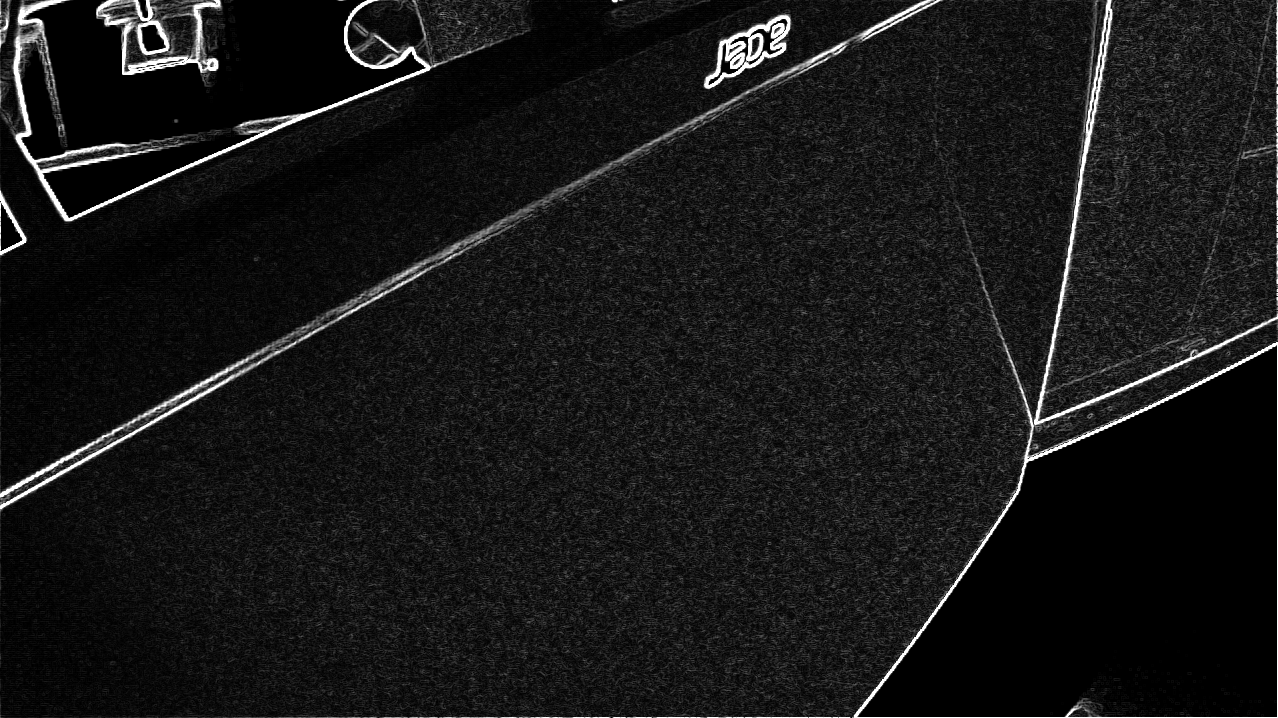

In [5]:
import cv2

img_shape = (720, 1280)
output_shape = (718, 1278)
input_buffer = allocate(shape=img_shape, dtype=np.uint8)
output_buffer = allocate(shape=output_shape, dtype=np.uint8)

input_buffer[:] = mipi.readframe()[:, :, 0]
dma_send.transfer(input_buffer)
dma_recv.transfer(output_buffer)
dma_send.wait()
dma_recv.wait()
PIL.Image.fromarray(output_buffer)

In [ ]:
displayport = DisplayPort()
displayport.configure(VideoMode(1280, 720, 24), PIXEL_RGB)

from time import time

for _ in range (3000):
    start = time()
    dp_frame_buffer = displayport.newframe()
    dpnewframe = time() - start

    start = time()
    input_buffer[:] = mipi.readframe()[:, :, 0]
    mipireadframe = time() - start
    
    start = time()
    dma_send.transfer(input_buffer)
    dma_recv.transfer(output_buffer)
    dma_send.wait()
    dma_recv.wait()
    dmatransfer = time() - start

    start = time()
    dp_frame_buffer[:output_shape[0], :output_shape[1]] = output_buffer[:, :, np.newaxis]
    concatwrite = time() - start
    displayport.writeframe(dp_frame_buffer)

    
    print(dpnewframe, mipireadframe, dmatransfer, concatwrite)


0.0033693313598632812 0.0030336380004882812 0.009757041931152344 0.14206457138061523
0.0008087158203125 0.0028581619262695312 0.009840011596679688 0.1424694061279297
9.059906005859375e-05 0.0029315948486328125 0.009774208068847656 0.14290571212768555
0.0007648468017578125 0.0029191970825195312 0.009760856628417969 0.14237546920776367
9.34600830078125e-05 0.0028510093688964844 0.009789466857910156 0.1429438591003418
0.0007638931274414062 0.0029277801513671875 0.009769916534423828 0.1430816650390625
0.00011682510375976562 0.0029239654541015625 0.009825706481933594 0.14280939102172852
0.00012874603271484375 0.0029668807983398438 0.009747028350830078 0.14242935180664062
9.822845458984375e-05 0.002834320068359375 0.00978851318359375 0.14300107955932617
0.0007996559143066406 0.0029425621032714844 0.009766578674316406 0.1424703598022461
9.34600830078125e-05 0.0028200149536132812 0.009776115417480469 0.1430196762084961
0.0007991790771484375 0.0029845237731933594 0.009765148162841797 0.14234066

9.107589721679688e-05 0.003180980682373047 0.009759902954101562 0.14280128479003906
0.0007662773132324219 0.0029668807983398438 0.00975799560546875 0.14228200912475586
9.393692016601562e-05 0.0028481483459472656 0.009776592254638672 0.1429448127746582
0.0007839202880859375 0.002933025360107422 0.009801864624023438 0.1424398422241211
0.0001049041748046875 0.0029296875 0.009768486022949219 0.14275217056274414
0.0007953643798828125 0.0029168128967285156 0.009775161743164062 0.14248371124267578
0.0001239776611328125 0.0030307769775390625 0.009778976440429688 0.14325428009033203
0.00012922286987304688 0.0029506683349609375 0.009760856628417969 0.15575265884399414
0.000125885009765625 0.003426074981689453 0.009793758392333984 0.15502262115478516
0.0008120536804199219 0.003448963165283203 0.009788990020751953 0.1572256088256836
0.00012683868408203125 0.0030150413513183594 0.009777545928955078 0.1690053939819336
0.00014066696166992188 0.003066539764404297 0.009799957275390625 0.151237010955810

0.00011920928955078125 0.003051280975341797 0.009770393371582031 0.14261770248413086
0.000125885009765625 0.002956867218017578 0.009737968444824219 0.14237213134765625
9.1552734375e-05 0.0027456283569335938 0.009775161743164062 0.14289188385009766
0.0007519721984863281 0.002940654754638672 0.009783267974853516 0.14244699478149414
9.632110595703125e-05 0.0028076171875 0.009754657745361328 0.1428666114807129
0.0007920265197753906 0.0034117698669433594 0.009776592254638672 0.14298629760742188
0.00011730194091796875 0.0029249191284179688 0.009768009185791016 0.14279794692993164
0.0007805824279785156 0.002986431121826172 0.00976705551147461 0.14502239227294922
0.000110626220703125 0.0028781890869140625 0.009817123413085938 0.14289236068725586
0.0007967948913574219 0.0029439926147460938 0.009758949279785156 0.14231443405151367
9.5367431640625e-05 0.0028204917907714844 0.009777069091796875 0.14278316497802734
0.0007848739624023438 0.0029325485229492188 0.009768009185791016 0.1424427032470703


9.5367431640625e-05 0.0029191970825195312 0.009778976440429688 0.14272117614746094
0.0007228851318359375 0.0029549598693847656 0.009781837463378906 0.1426372528076172
0.00011205673217773438 0.0030241012573242188 0.009772777557373047 0.1434326171875
0.000133514404296875 0.0029172897338867188 0.009736061096191406 0.14273738861083984
9.584426879882812e-05 0.0028519630432128906 0.0097808837890625 0.14267206192016602
0.0007114410400390625 0.0029048919677734375 0.009772300720214844 0.1424846649169922
0.0001010894775390625 0.00286865234375 0.009902000427246094 0.14296960830688477
0.0008158683776855469 0.002899646759033203 0.009761333465576172 0.14246082305908203
9.5367431640625e-05 0.0028166770935058594 0.009819507598876953 0.14269208908081055
0.0007338523864746094 0.0029349327087402344 0.009758949279785156 0.14250755310058594
0.00011396408081054688 0.002902984619140625 0.009800434112548828 0.14282560348510742
0.0007414817810058594 0.00293731689453125 0.009778022766113281 0.14249372482299805


0.00011539459228515625 0.002997875213623047 0.009759902954101562 0.14278745651245117
0.000701904296875 0.002930164337158203 0.009763240814208984 0.14234161376953125
9.202957153320312e-05 0.0028371810913085938 0.009827613830566406 0.1428360939025879
0.0007510185241699219 0.0029740333557128906 0.009760379791259766 0.14243316650390625
9.965896606445312e-05 0.0028214454650878906 0.009769439697265625 0.14276885986328125
0.0007729530334472656 0.002941608428955078 0.009784221649169922 0.14217567443847656
0.00015544891357421875 0.002933979034423828 0.00989532470703125 0.1437516212463379
0.0007882118225097656 0.002922534942626953 0.009772777557373047 0.14233636856079102
9.679794311523438e-05 0.002830982208251953 0.009761333465576172 0.14287519454956055
0.0007987022399902344 0.0029468536376953125 0.009776115417480469 0.14231538772583008
9.632110595703125e-05 0.0028352737426757812 0.009771347045898438 0.14301109313964844
0.0007772445678710938 0.002925395965576172 0.00975799560546875 0.14236593246

...

8.96453857421875e-05 0.002849102020263672 0.009770870208740234 0.1431431770324707
0.0008153915405273438 0.0029425621032714844 0.009772300720214844 0.14229631423950195
0.00010728836059570312 0.002795696258544922 0.009778499603271484 0.14280176162719727
0.0007739067077636719 0.002960205078125 0.009771347045898438 0.14243507385253906
9.250640869140625e-05 0.0027942657470703125 0.009787559509277344 0.1428365707397461
0.000766754150390625 0.0029554367065429688 0.00975656509399414 0.14234447479248047
9.441375732421875e-05 0.003268718719482422 0.009763717651367188 0.1428532600402832
0.0007801055908203125 0.0029621124267578125 0.009791374206542969 0.14240550994873047
9.822845458984375e-05 0.003330707550048828 0.009767532348632812 0.14276742935180664
0.0007977485656738281 0.0029611587524414062 0.00977182388305664 0.14234209060668945
9.632110595703125e-05 0.0028219223022460938 0.009763717651367188 0.1428680419921875
0.0007796287536621094 0.002948760986328125 0.009838581085205078 0.14231300354003

9.1552734375e-05 0.003200531005859375 0.009789466857910156 0.14284372329711914
0.0007915496826171875 0.0029630661010742188 0.009756088256835938 0.14221811294555664
9.679794311523438e-05 0.0028929710388183594 0.009763717651367188 0.14277124404907227
0.0007205009460449219 0.0028824806213378906 0.009813785552978516 0.14236783981323242
0.00010156631469726562 0.0029478073120117188 0.009770870208740234 0.14283418655395508
0.0007767677307128906 0.0029158592224121094 0.009828567504882812 0.1423330307006836
0.00010824203491210938 0.0029616355895996094 0.009755134582519531 0.1427936553955078
0.0007305145263671875 0.0028839111328125 0.009757518768310547 0.14244556427001953
9.441375732421875e-05 0.0028595924377441406 0.009759902954101562 0.1427140235900879
0.0007543563842773438 0.0029191970825195312 0.009775161743164062 0.1425952911376953
0.00011110305786132812 0.0029611587524414062 0.00982046127319336 0.14299488067626953
0.0001316070556640625 0.0034027099609375 0.00975656509399414 0.1423802375793

9.632110595703125e-05 0.0029349327087402344 0.009766101837158203 0.14281082153320312
0.0007009506225585938 0.002910614013671875 0.009759902954101562 0.14245319366455078
0.00011157989501953125 0.0030045509338378906 0.009752273559570312 0.1427936553955078
0.0008020401000976562 0.0033240318298339844 0.009747982025146484 0.14232873916625977
9.489059448242188e-05 0.0028018951416015625 0.009753704071044922 0.1428203582763672
0.0007791519165039062 0.0029249191284179688 0.009757518768310547 0.14221763610839844
9.250640869140625e-05 0.0027723312377929688 0.009777069091796875 0.14304161071777344
0.0007882118225097656 0.0029153823852539062 0.009763240814208984 0.14243650436401367
0.0001087188720703125 0.002959728240966797 0.00975656509399414 0.14281797409057617
0.0007185935974121094 0.003245830535888672 0.009762287139892578 0.14223766326904297
9.584426879882812e-05 0.0028352737426757812 0.009755134582519531 0.14301538467407227
0.0006875991821289062 0.0029268264770507812 0.00975942611694336 0.1424

0.00014448165893554688 0.002979278564453125 0.009764671325683594 0.14403247833251953
0.0008149147033691406 0.002964496612548828 0.00976705551147461 0.1423640251159668
9.441375732421875e-05 0.002849102020263672 0.009777069091796875 0.14279985427856445
0.0007748603820800781 0.002964019775390625 0.0097503662109375 0.14272737503051758
0.00011444091796875 0.0029625892639160156 0.009754180908203125 0.1432185173034668
0.0008211135864257812 0.0029458999633789062 0.009823799133300781 0.14235782623291016
9.298324584960938e-05 0.0028581619262695312 0.009763717651367188 0.14270782470703125
0.0008349418640136719 0.003616809844970703 0.009768486022949219 0.14249753952026367
9.870529174804688e-05 0.0028443336486816406 0.009742259979248047 0.14280080795288086
0.0007786750793457031 0.0029077529907226562 0.009777069091796875 0.14235448837280273
9.298324584960938e-05 0.0027942657470703125 0.009814262390136719 0.14280080795288086
0.0008111000061035156 0.0029354095458984375 0.009754657745361328 0.142301559

0.0001220703125 0.0029850006103515625 0.009827136993408203 0.14277935028076172
0.0007543563842773438 0.0029401779174804688 0.009773731231689453 0.1423478126525879
0.00010919570922851562 0.0029115676879882812 0.009852886199951172 0.14281129837036133
0.0007596015930175781 0.002941608428955078 0.009760379791259766 0.1426067352294922
0.00011348724365234375 0.0029268264770507812 0.009762287139892578 0.14287471771240234
0.0007781982421875 0.0029401779174804688 0.009768009185791016 0.14236211776733398
9.1552734375e-05 0.0028295516967773438 0.009774208068847656 0.14279413223266602
0.0007576942443847656 0.0029778480529785156 0.009748458862304688 0.14279985427856445
0.00012111663818359375 0.0029807090759277344 0.009754657745361328 0.14273834228515625
0.0007681846618652344 0.00296783447265625 0.009757518768310547 0.1425027847290039
0.0001125335693359375 0.0029544830322265625 0.009765625 0.14284276962280273
0.0007719993591308594 0.0029854774475097656 0.00975942611694336 0.14241647720336914
0.00010

In [ ]:
displayport.close()
mipi.stop()